In [40]:
import math
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('ggplot')


## Geometric Brownian Motion (GBM)
$S(t+\Delta t)=S(t)\exp^{(\mu-0.5\sigma^2)\Delta t+\sigma\epsilon\sqrt{\Delta t}}$<br>

- $S(t)$:當前資產價格。
- $S(t+\Delta t)$:未來資產價格。
- $\mu$ (Drift):期望報酬率。
- $\sigma$ (Volatility):波動率。
- $\Delta t$:時間間隔。
- $\epsilon$: random variable from standard normal distribution. $\epsilon\sim{N(0,1)}$

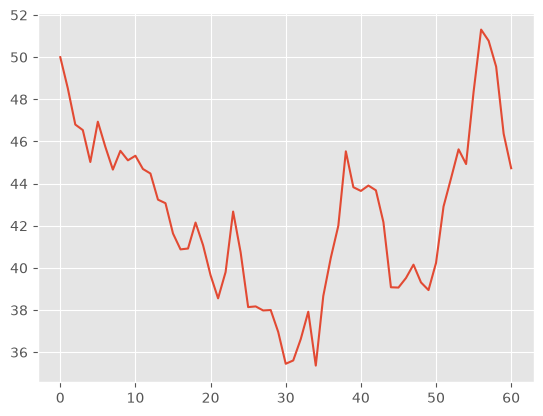

In [43]:
S0 = 50  # Current stock price
K = 40   # Strike price
r = 0.08  # Risk-free interest rate (annualized)
T = 2    # Time to expiration (in years)
v = 0.2  # Volatility of the stock (annualized)

def gbm(S, T, r, v, trading_days=60):
    dt = T / trading_days
    S_t = np.zeros(trading_days+1)
    S_t[0] = S
    
    for t in range(trading_days):
        epsilon = np.random.normal()
        S_t[t+1] = S_t[t] * np.exp((r - 0.5 * v**2) * dt + v * epsilon * np.sqrt(dt))
        
    return S_t

plt.plot(gbm(S0, T, r, v, trading_days=60))

np.float64(46.846367551017835)

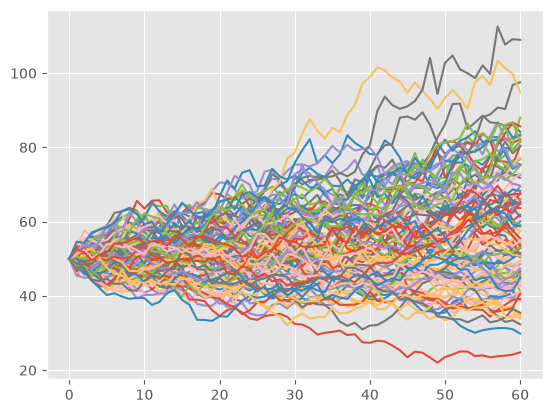

In [44]:
def plot_monte_carlo(S0, K, r, T, v, num_simulations=5000, trading_days=60):
    last_prices = 0
    prices_matrix = np.zeros((num_simulations, trading_days+1))
    
    for i in range(num_simulations):
        prices_matrix[i] = gbm(S0, T, r, v, trading_days)
        if prices_matrix[i][-1] > K:
            last_prices += prices_matrix[i][-1]
    
    expected_price = last_prices * np.exp(-r * T) / num_simulations
    plt.plot(prices_matrix.T)        
    
    return expected_price
    
plot_monte_carlo(S0, K, r, T, v, num_simulations=100, trading_days=60)